In [1]:
# notebook to filter promoterAI predictions for comparisons across models
# also convert predictions to tensors for generating seqlets

In [28]:
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
import pickle
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

In [2]:
# load merged predictions
all_preds = pd.read_csv('../processed_data/all.merged.250bp.promoter.preds.pAI.parm.mpac.dropNA.tsv', sep = '\t', low_memory = False)

In [3]:
all_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,hepg2_parm_act,k562_parm_act,promoterAI_score,parm_k562_pred,parm_hepg2_pred,parm_mean_pred,parm_k562_emVar,parm_hepg2_emVar,parm_emVar_any,mpac_mean_skew
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,...,0.667815,0.166738,0.005,-0.002416,0.002983,0.000283,0,0,0,-0.000599
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,...,0.667815,0.166738,-0.002,-0.001053,0.004086,0.001516,0,0,0,-0.006068
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,...,0.667815,0.166738,-0.003,-0.001701,-0.000167,-0.000934,0,0,0,-0.021297
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,...,0.667815,0.166738,0.010,0.000088,0.000730,0.000409,0,0,0,0.071461
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,C,0.287499,0.300818,0.013319,0.352586,0.341317,...,0.667815,0.166738,0.002,0.000470,-0.000271,0.000100,0,0,0,-0.010420


Text(0.5, 1.0, 'n promoter predictions per gene | 17392 total genes')

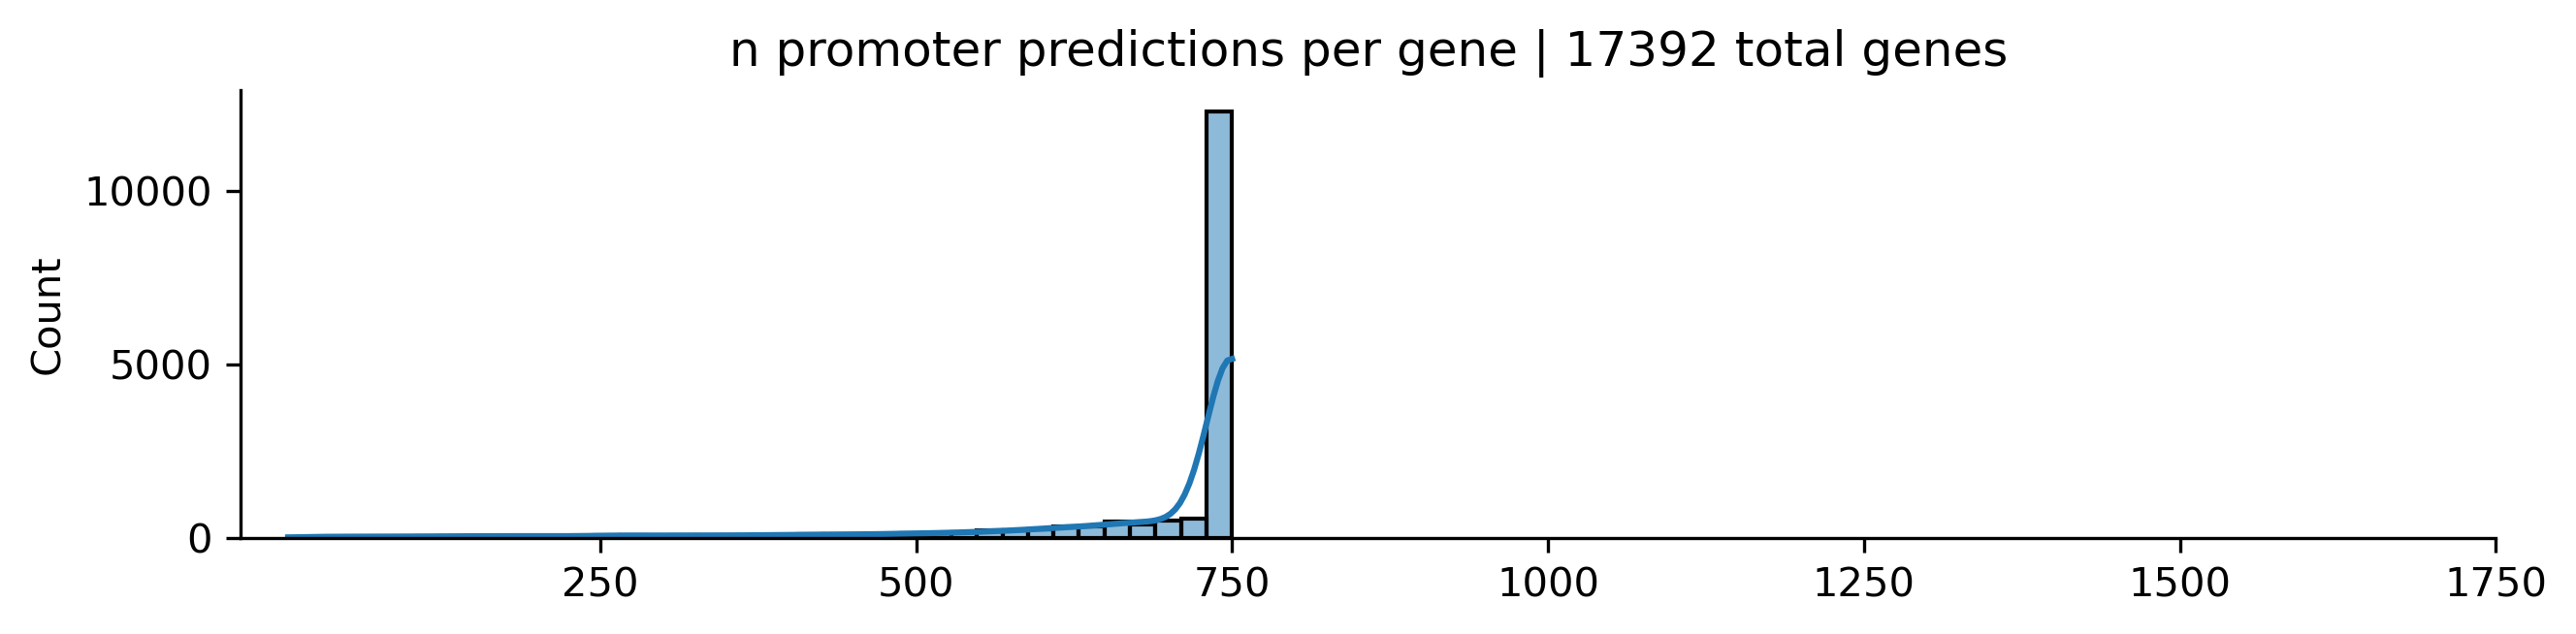

In [4]:
# plot distribution of promoter lengths - most should be 750bp
mpl.figure(dpi=300, figsize=(10,2))
sns.histplot(Counter(all_preds['gene_id']).values(), binwidth=20, kde=True, legend=False)
mpl.xticks([250, 500, 750, 1000, 1250, 1500, 1750],
           [250, 500, 750, 1000, 1250, 1500, 1750])
sns.despine()
mpl.title(f'n promoter predictions per gene | {len(all_preds['gene_id'].unique())} total genes')

In [5]:
# reformat predictions for converting to tensors
promoterAI_4_tensors = pd.DataFrame({'chrom' : all_preds['chrom'],
                                     'pos' : all_preds['pos'],
                                     'id' : all_preds['gene_id'],
                                     'ref' : all_preds['ref'],
                                     'alt' : all_preds['alt'],
                                     'score' : all_preds['promoterAI_score']})

In [6]:
promoterAI_4_tensors.head()

,chrom,pos,id,ref,alt,score
0,chr1,65169,ENSG00000186092.7,A,C,0.005
1,chr1,65169,ENSG00000186092.7,A,G,-0.002
2,chr1,65169,ENSG00000186092.7,A,T,-0.003
3,chr1,65170,ENSG00000186092.7,G,A,0.010
4,chr1,65170,ENSG00000186092.7,G,C,0.002


In [7]:
def predictions_to_tensors(df, target_length=250):
    """
    Converts a DataFrame of saturation mutagenesis predictions into a
    dictionary of tensors, designed for a single score column.

    Args:
        df (pd.DataFrame): 
            DataFrame with columns ['id', 'pos', 'ref', 'alt', 'score'].

    Returns:
        dict: A dictionary where keys are unique 'id' values and
              values are (4, sequence_length) PyTorch tensors.
    """
    # make a list for storing misfitting genes #
    misfit_genes = []
    
    # A mapping from DNA base to the tensor row index
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    tensor_dict = {}
    
    # Group the entire DataFrame by the promoter ID
    # This yields a promoter_id (e.g., 'OR4F5') and a DataFrame (promoter_df) for that ID
    for promoter_id, promoter_df in tqdm(df.groupby('id'), desc="Converting promoters to tensors"):
        
        position_vectors = []
        
        # Within each promoter's data, group by position and sort to ensure order
        # The sort is crucial for ensuring the tensor sequence is correct
        for pos, pos_df in promoter_df.groupby('pos'):
            
            # Create a 4-element vector [A, C, G, T] initialized to zero
            score_vector = [0.0] * 4
            
            # Fill in the scores for the 3 alternate bases
            for _, row in pos_df.iterrows():
                alt_base_index = base_map[row['alt'].upper()]
                score_vector[alt_base_index] = row['score']
                
            position_vectors.append(score_vector)
            
        # Convert the list of position vectors into a single tensor
        # and transpose it to get the desired (4, seq_len) shape
        final_tensor = torch.tensor(position_vectors, dtype=torch.float32).T
        # Check the length of the tensor
        current_length = final_tensor.shape[-1]
            
        if current_length == target_length:
            tensor_dict[promoter_id] = final_tensor
        elif current_length < target_length:
            # Pad with zeros to reach target_length
            padding_size = target_length - current_length
            padding = torch.zeros((4, padding_size), dtype=torch.float32)
            padded_tensor = torch.cat([final_tensor, padding], dim=1)
            tensor_dict[promoter_id] = padded_tensor
        else:
            # Longer than expected - mark as misfit
            misfit_genes.append(promoter_id)
        
    return tensor_dict, misfit_genes;

In [8]:
# generate raw tensors
promoterAI_raw_tensors, misfit_genes = predictions_to_tensors(promoterAI_4_tensors)

Converting promoters to tensors: 100%|██████████| 17392/17392 [10:44<00:00, 26.97it/s]


In [9]:
# store the tensor dict keys as a list for retaining indexing
gene_name_list = list(promoterAI_raw_tensors.keys())
# stack tensors
raw_stack = torch.stack([promoterAI_raw_tensors.get(i) for i in gene_name_list])

In [10]:
# define function for returning tensors for recursive seqlets, plotLogos (contributions), and oneHot encoded (for annotations)
def tensors4tangermeme (stacked_raw_tensors, gene_list):
    # make empty dictionaries for each type of seqlet to return
    seqlet_dict = {}
    plotLogo_dict = {}
    oneHot_dict = {}

    # iterate through stacked tensors and modify for each type
    for index, promoter in enumerate(gene_list):
        # pull the tensor to modify
        raw_tensor = stacked_raw_tensors[index]
        # make oneHot tensor
        oneHot_tensor = 1 * (raw_tensor == 0)
        # make seqlet tensor
        seqlet_tensor = (-1 * (raw_tensor.sum(dim=0))) / 3
        # make plot logo tensor
        plotLogo_tensor = oneHot_tensor * seqlet_tensor
        # update dictionaries
        seqlet_dict[promoter] = seqlet_tensor
        plotLogo_dict[promoter] = plotLogo_tensor
        oneHot_dict[promoter] = oneHot_tensor
    return seqlet_dict, plotLogo_dict, oneHot_dict;

In [11]:
# generate tensors for calling with tangermeme
promoterAI_seqlet_tensors, promoterAI_plotLogo_tensors, promoterAI_oneHot_tensors = tensors4tangermeme(raw_stack, gene_name_list)

In [12]:
# stack all tensors
pAI_seqlet_stack = torch.stack([promoterAI_seqlet_tensors.get(i) for i in gene_name_list])
pAI_plotLogo_stack = torch.stack([promoterAI_plotLogo_tensors.get(i) for i in gene_name_list])
pAI_oneHot_stack = torch.stack([promoterAI_oneHot_tensors.get(i) for i in gene_name_list])

In [13]:
# call recursive seqlets
promoterAI_seqlet_calls = recursive_seqlets(pAI_seqlet_stack, threshold=0.01)

In [14]:
promoterAI_seqlet_calls

,example_idx,start,end,attribution,p-value
0,5913,228,243,12.916667,2.952083e-13
1,9995,220,237,13.447667,4.557549e-07
2,9819,129,148,-12.135000,5.432676e-07
3,9820,205,224,-12.135000,5.432676e-07
4,8330,200,210,9.167333,9.162836e-07
...,...,...,...,...,...
15230,10413,19,23,2.307667,9.999408e-03
15231,17295,74,78,2.307333,9.999408e-03
15232,4836,179,183,2.304667,9.999408e-03
15233,4835,107,111,2.304333,9.999408e-03


In [15]:
### Annotate Seqlets ###
# define the path to the meme motifs as a variable for annotating seqlets
pwm_dir = '/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/'
# open pwms
motifs = read_meme(f'{pwm_dir}/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme')
motif_names = list(motifs.keys())

# run annotate seqlets
motif_idxs, motif_pvals = annotate_seqlets(pAI_oneHot_stack, promoterAI_seqlet_calls, f'{pwm_dir}/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme')

In [16]:
# make a dictionary of indices and gene names for annotating promoters
promoter_idx_dict = dict(zip([gene_name_list.index(i) for i in gene_name_list], gene_name_list))

In [17]:
# make copies of the seqlet DFs for annotating with promoter names and tf names
# tf for plotLogos
tf_ann_seqlets = promoterAI_seqlet_calls.copy()
tf_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs] # use this one with plotLogos
# tf + promoter id
full_ann_seqlets = promoterAI_seqlet_calls.copy()
# add enhancer ids
full_ann_seqlets.loc[:, 'promoter_id'] = [promoter_idx_dict.get(i) for i in full_ann_seqlets['example_idx']]
# add matching motif
full_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs]
# add pval of match
full_ann_seqlets.loc[:,'pval'] = [float(i[0]) for i in motif_pvals]

/tmp/ipykernel_1857843/2094201205.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['IRF2_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'E2F5_HUMAN.H11MO.0.B', 'E2F5_HUMAN.H11MO.0.B', 'KAISO_HUMAN.H11MO.0.A', 'PRDM1_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'STAT1_HUMAN.H11MO.0.A', 'E2F3_HUMAN.H11MO.0.A', 'IRF9_HUMAN.H11MO.0.C', 'E2F1_HUMAN.H11MO.0.A', 'DUX4_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'IRF9_HUMAN.H11MO.0.C', 'ZN329_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'E2F5_HUMAN.H11MO.0.B', 'ZSC22_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'E2F5_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'ETV1_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'SPIB_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'ELK1_HUMAN.H11MO.0.B', 'MECP2_HUMAN.H11MO.0.C', 'E2F4_HUMAN.H11MO.0.A', 'IRF9_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'GABPA_HUMAN.H11MO.0.A', 'IRF2_HUMAN.H11MO.0.A', 'ATF2_HUMAN.H11MO.0.B', 'TF65_HUMAN.H11MO.

In [18]:
full_ann_seqlets.sort_values(by='promoter_id')

,example_idx,start,end,attribution,p-value,promoter_id,pval
1396,E2F5_HUMAN.H11MO.0.B,120,129,-3.890000,0.001018,ENSG00000000460.17,4.615354e-04
12480,INSM1_HUMAN.H11MO.0.C,113,119,-1.496333,0.008499,ENSG00000000938.13,1.037145e-07
3328,USF1_HUMAN.H11MO.0.A,5,11,4.117333,0.002514,ENSG00000001036.14,5.754051e-05
5934,MAFG_HUMAN.H11MO.0.A,11,15,2.749667,0.004390,ENSG00000001036.14,7.251773e-05
2043,ERR1_HUMAN.H11MO.0.A,12,17,3.825000,0.001529,ENSG00000001036.14,2.907415e-05
...,...,...,...,...,...,...,...
3499,NRF1_HUMAN.H11MO.0.A,83,88,3.570000,0.002640,ENSG00000289791.1,1.182353e-04
13971,NRF1_HUMAN.H11MO.0.A,64,68,2.345333,0.009340,ENSG00000289791.1,1.105003e-03
10583,MYF6_HUMAN.H11MO.0.C,82,86,2.479000,0.007405,ENSG00000289791.1,2.667632e-04
10541,GABPA_HUMAN.H11MO.0.A,157,162,2.963667,0.007362,ENSG00000290149.1,1.206333e-05


In [19]:
def plot_specific_logos (seqlets,
                         annotated_seqlets,
                         promoter_id,
                         plotLogo_tensors):
    
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    if len(pro_seqlets) > 0:
        mpl.figure(figsize=(20,1), dpi=300)
        ax = mpl.subplot(111)
        plot_logo(plotLogo_tensors[promoter_id], annotations=pro_ann, score_key='attribution')
        for idx, row in pro_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.15, color='palevioletred')
        #mpl.ylim(-.5, .5)
        mpl.title(f'tangermeme seqlets for {promoter_id}')
        mpl.show()
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[promoter_id])
        mpl.title(f'tangermeme seqlets for {promoter_id}')
        mpl.show()

In [20]:
# define the optimized function for converting seqlets to a bed file
def seqlets2bed_optimized(full_preds,
                          full_ann_seqlets):
    """
    Converts seqlet predictions to a BED DataFrame using vectorized operations.
    """
    # 1. Get min position for each enhancer. This is already efficient.
    # The result is a Series where the index is 'id' and values are the min 'pos'.
    promoter_min_pos = full_preds.groupby('id')['pos'].min()
    promoter_chrom = full_preds.groupby('id')['chrom'].min()
    #promoter_attrib = 
    # Get the seqlets DataFrame from your dictionary
    seqlets = full_ann_seqlets.copy() # Use .copy() to avoid SettingWithCopyWarning

    # 2. Map the enhancer start positions to each seqlet.
    # This single vectorized operation replaces your entire outer 'for enh...' loop.
    seqlets['promoter_start'] = seqlets['promoter_id'].map(promoter_min_pos)
    seqlets['chrom'] = seqlets['promoter_id'].map(promoter_chrom)
    # Drop any seqlets whose enhancer_id was not found in 'full_preds'
    seqlets.dropna(subset=['promoter_start'], inplace=True)
    
    # Ensure the new column is an integer type for calculations
    seqlets['promoter_start'] = seqlets['promoter_start'].astype(int)

    # 3. Calculate BED coordinates and IDs vectorially.
    # These three lines replace your inner loop and all list appends.
    bed_start = seqlets['promoter_start'] + seqlets['start'] - 1 # Convert to 0-based
    bed_end = seqlets['promoter_start'] + seqlets['end']
    bed_id = seqlets['example_idx'].astype(str) + '_' + seqlets['promoter_id']
    # append attribution to id
    bed_id = [f'{i}_{str(j)}' for i, j in zip(bed_id, seqlets['attribution'].tolist())]
    chromosome = seqlets['chrom']
    # 4. Assemble the final DataFrame in one step.
    bed2return = pd.DataFrame({
        'chrom': chromosome,
        'start': bed_start,
        'end': bed_end,
        'id': bed_id
    }).sort_values(by=['chrom', 'start'])
    
    return bed2return

In [21]:
promoterAI_seqlet_bed = seqlets2bed_optimized(promoterAI_4_tensors,
                                              full_ann_seqlets)

In [22]:
promoterAI_seqlet_bed.head()

,chrom,start,end,id
5870,chr1,959266,959273,GABPA_HUMAN.H11MO.0.A_ENSG00000188976.11_3.781...
7097,chr1,966379,966387,SNAI1_HUMAN.H11MO.0.C_ENSG00000187583.11_-2.04...
12442,chr1,966457,966462,SP1_HUMAN.H11MO.0.A_ENSG00000187583.11_2.40299...
99,chr1,1013389,1013402,IRF9_HUMAN.H11MO.0.C_ENSG00000187608.10_9.2199...
10925,chr1,1013446,1013451,ATF6A_HUMAN.H11MO.0.B_ENSG00000187608.10_2.461...


In [29]:
# save annotated seqlets and things needed for plotting to disk
promoterAI_seqlet_calls.to_csv('../promoterAI/processed_data/promoterAI_seqlet_calls.tsv', sep = '\t', index = False)
full_ann_seqlets.to_csv('../promoterAI/processed_data/promoterAI_full_ann_seqlets.tsv', sep = '\t', index = False)
with open('../promoterAI/processed_data/promoterAI_plotLogo_dict.pkl', 'wb') as f: # Open in write binary mode ('wb')
    pickle.dump(promoterAI_plotLogo_tensors, f)

In [63]:
#promoterAI_seqlet_bed.to_csv('../processed_data/bed_files/promoterAI_annotated_seqlets_01.bed', sep = '\t', index = False)

In [ ]:
####### STOP HERE 11/30/25 #######
# open the BED files for each method and do an analysis this way in another notebook #

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

def seqlet_summary_single_group(path2bedtools_coverage,
                                plot_color,
                                 min_overlap):
    """
    Generates a 5-panel summary plot for a single group of enhancers.
    """
    # --- Data Loading and Preparation ---
    coverage_cols = [
        'cre_chrom', 'cre_start', 'cre_end', 'promoter', 'cre_id', 'cre_strand',
        'n_seqlets', 'n_bases_covered', 'cre_length', 'fraction_covered'
    ]
    bed_covers = pd.read_csv(path2bedtools_coverage, sep='\t', header=None, names=coverage_cols)
    bed_covers = bed_covers[bed_covers['cre_chrom'] != 'chrX']
    
    bed_covers['seqlet_density'] = (bed_covers['n_seqlets'] / (bed_covers['cre_length'] + 1e-9)) * 50
    
    if bed_covers.empty:
        print(f"Warning: No data remains for promoterAI after processing. Skipping plot.")
        return
    
    # Use a 2x3 grid and hide the last panel
    f, axes = plt.subplots(1, 3, figsize=(6, 3), dpi=300)
    axes = axes.flatten()
    
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    # --- Create All Plots for the Single Group ---
    # Panel 1: n_seqlets (ECDF)
    sns.ecdfplot(data=bed_covers, x='n_seqlets', color=plot_color, ax=axes[0])
    axes[0].set_title(f'promoterAI | merge min overlap: {min_overlap}', loc='left')
    axes[0].set_xlabel("n_seqlets")

    # Panel 2: fraction_covered (ECDF)
    sns.ecdfplot(data=bed_covers, x='fraction_covered', color=plot_color, ax=axes[1])
    axes[1].set_ylabel("")

    # Panel 3: seqlet_density (ECDF)
    sns.ecdfplot(data=bed_covers, x='seqlet_density', color=plot_color, ax=axes[2])
    axes[2].set_xlabel('Seqlets per 50bp')
    axes[2].set_ylabel("")

    sns.despine()
    plt.tight_layout()

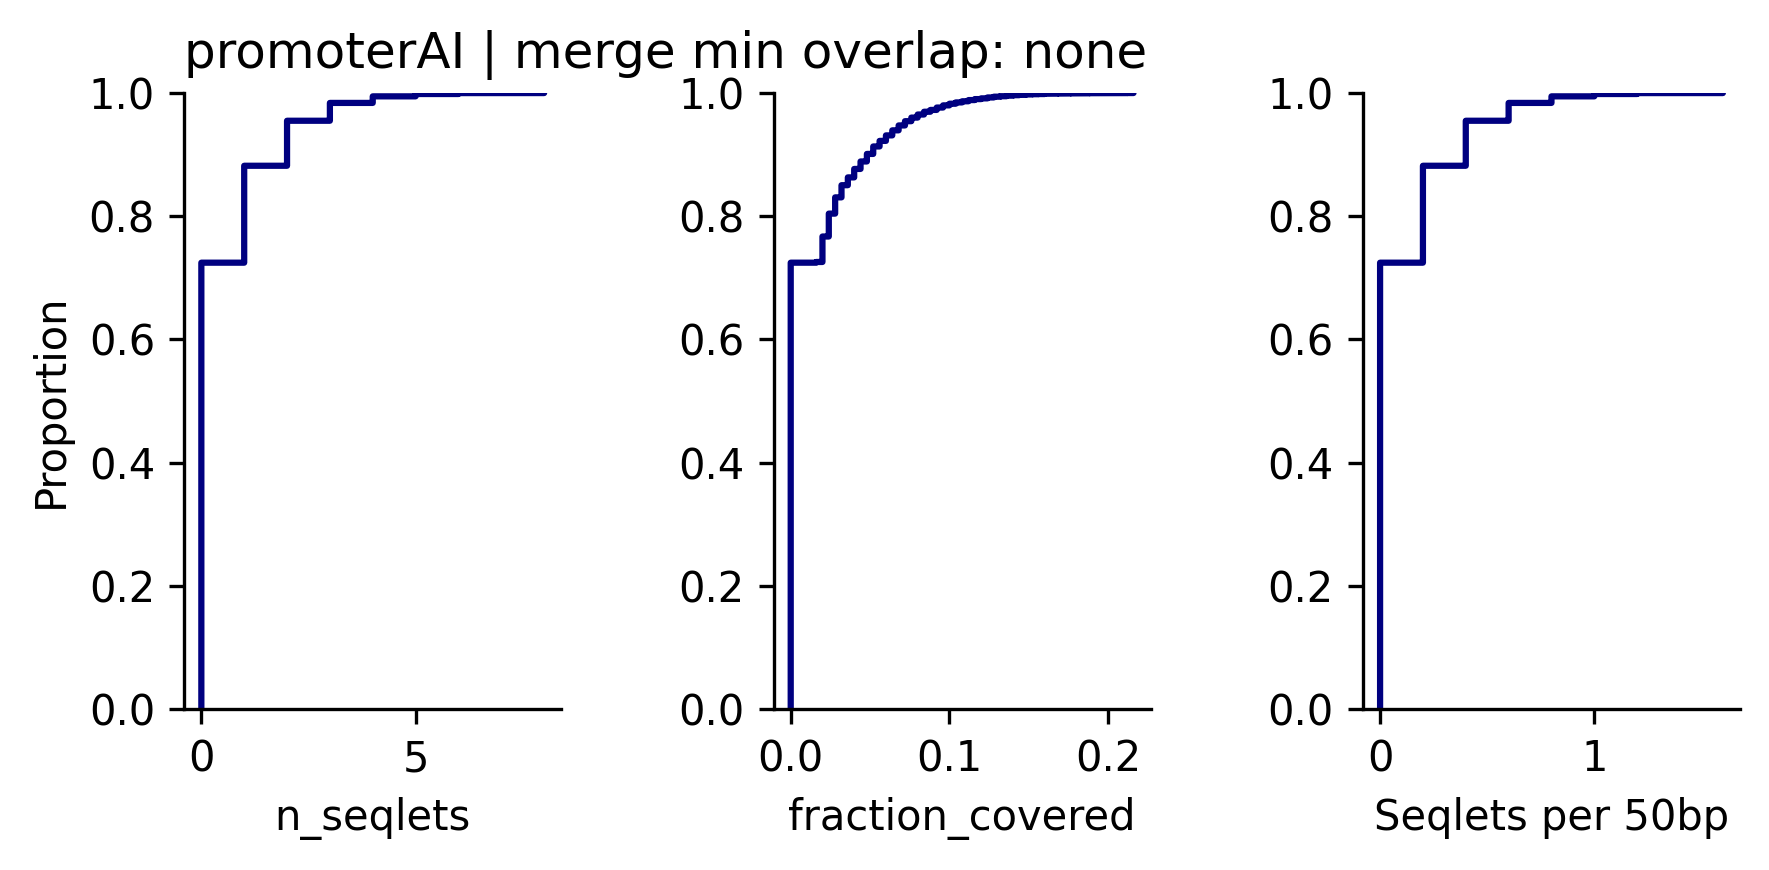

In [28]:
seqlet_summary_single_group('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/promoterAI_01_noMin_250bp_pro_cover.bed',
                            'navy',
                            'none')

In [29]:
def assign_representative_tf(bed_file):
    """
    Reads a mapped BED file, assigns a single representative TF, and
    classifies its activity based on attribution score.

    Args:
        bed_file (pd.DataFrame): DataFrame from the bedmap output.

    Returns:
        pd.DataFrame: The original DataFrame with two new columns:
                      'representative_tf' and 'activity_class'.
    """
    df = bed_file
    data_column_index = 3

    representative_tfs = []
    activity_classes = [] # New list to store the activity class

    for index, row in df.iterrows():
        mapped_info_string = str(row[data_column_index])
        tf_hits = mapped_info_string.split(';')
        
        best_tf = ''
        best_score = 0.0 # Variable to hold the signed score of the winner
        
        if len(tf_hits) == 1:
            # RULE 1: Only one TF is present
            parts = tf_hits[0].split('_')
            best_tf = parts[0]
            try:
                best_score = float(parts[-1])
            except (ValueError, IndexError):
                best_score = 0.0 # Default if score is missing
        else:
            # RULES 2 & 3: Multiple TFs are present
            max_abs_attribution = -1.0
            all_tf_names = set()
            
            for hit in tf_hits:
                parts = hit.split('_')
                tf_name = parts[0]
                all_tf_names.add(tf_name)
                
                try:
                    attribution_score = float(parts[-1])
                    if abs(attribution_score) > max_abs_attribution:
                        max_abs_attribution = abs(attribution_score)
                        best_tf = tf_name
                        best_score = attribution_score # Store the signed score
                except (ValueError, IndexError):
                    continue
            
            if len(all_tf_names) == 1:
                # RULE 2: Motifs are the same, just use the single name
                best_tf = list(all_tf_names)[0]

        # Append the chosen TF and determine its class
        representative_tfs.append(best_tf)
        
        if best_score > 0:
            activity_classes.append('Activator')
        elif best_score < 0:
            activity_classes.append('Repressor')
        else:
            activity_classes.append('Neutral') # For scores of 0 or errors

    # Add the two new columns to the DataFrame
    df['representative_tf'] = representative_tfs
    df['activity_class'] = activity_classes
    
    return df

In [30]:
# open merged bed file
promoterAI_merged_noMin = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/promoterAI_bedOps_merged_noMin_seqlets_01.bed',
                                      sep = '\t',
                                      header = None)

In [31]:
promoterAI_merged_noMin

,0,1,2,3
0,chr1,966379,966387,SNAI1_HUMAN.H11MO.0.C_PLEKHN1_-2.0443333201110363
1,chr1,966457,966462,SP1_HUMAN.H11MO.0.A_PLEKHN1_2.4029999375343323
2,chr1,1000185,1000190,FOXI1_HUMAN.H11MO.0.B_HES4_2.2360000610351562
3,chr1,1214252,1214258,ZBT7A_HUMAN.H11MO.0.A_TNFRSF4_-1.45899997651577
4,chr1,1273867,1273875,ELK1_HUMAN.H11MO.0.B_UBE2J2_4.85933318734169
...,...,...,...,...
8488,chr9,137578925,137578935,NR5A2_HUMAN.H11MO.0.B_DPH7_2.4006667137145996;...
8489,chr9,137578947,137578956,ELK1_HUMAN.H11MO.0.B_DPH7_5.911666721105576
8490,chr9,137590684,137590690,SP1_HUMAN.H11MO.0.A_ZMYND19_-1.31133334338665
8491,chr9,137590710,137590725,E2F5_HUMAN.H11MO.0.B_ZMYND19_-6.387333333492279


In [32]:
# collapse TFs for each cell type
# k562
promoterAI_noMin_collapsed = assign_representative_tf(promoterAI_merged_noMin)

In [36]:
# save a copy of the collapsed seqlets to disk as a BED for annotating predictions with seqlet status
# we're doing this to check the correlations of variants called seqlets across prediction types
# we'll do this using the merged, collapsed intervals - doesn't really matter that they're collapsed as much as merged for this purpose
promoterAI_seqlet_bed4ann = pd.DataFrame({0 : promoterAI_noMin_collapsed[0],
                                          1 : promoterAI_noMin_collapsed[1],
                                          2 : promoterAI_noMin_collapsed[2],
                                          3 : [1 for i in range(len(promoterAI_noMin_collapsed))]})
# save it to disk
promoterAI_seqlet_bed4ann.to_csv('../processed_data/bed_files/promoterAI_merged_collapsed_seqlets4annotation.bed', sep = '\t', index = False, header = None)

In [35]:
promoterAI_seqlet_bed4ann

,0,1,2,3
0,chr1,966379,966387,1
1,chr1,966457,966462,1
2,chr1,1000185,1000190,1
3,chr1,1214252,1214258,1
4,chr1,1273867,1273875,1
...,...,...,...,...
8488,chr9,137578925,137578935,1
8489,chr9,137578947,137578956,1
8490,chr9,137590684,137590690,1
8491,chr9,137590710,137590725,1


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib # Import the full library to access rcParams

def plot_final_diverging_chart(df, output_path, cell_color, cell_color_repressor, top_n=10, plot_type='counts'):
    """
    Creates a publication-ready, stacked diverging bar plot with top N
    activators and repressors, featuring balanced axes and editable fonts.

    Args:
        df (pd.DataFrame): DataFrame with 'representative_tf' and 'activity_class'.
        output_path (str): Path to save the plot image (e.g., 'figure.pdf').
        top_n (int): Number of top TFs to display for each class.
        plot_type (str): 'counts' or 'percentages'.
    """
    # 1. Set Matplotlib parameters for editable text in Illustrator
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    if plot_type not in ['counts', 'percentages']:
        raise ValueError("plot_type must be 'counts' or 'percentages'")

    # 2. Separate and count data
    activators = df[df['activity_class'] == 'Activator']['representative_tf'].value_counts().head(top_n)
    repressors = df[df['activity_class'] == 'Repressor']['representative_tf'].value_counts().head(top_n)

    if plot_type == 'percentages':
        total_activators = df[df['activity_class'] == 'Activator'].shape[0]
        total_repressors = df[df['activity_class'] == 'Repressor'].shape[0]
        activators = (activators / total_activators * 100) if total_activators > 0 else activators
        repressors = (repressors / total_repressors * 100) if total_repressors > 0 else repressors
        x_label = 'Percentage of Total Calls'
    else:
        x_label = 'Count'

    # 3. Prepare data for plotting
    activator_tfs = activators.index.tolist()
    activator_values = activators.values
    repressor_tfs = repressors.index.tolist()
    repressor_values = -repressors.values

    repressor_tfs.reverse()
    repressor_values = np.flip(repressor_values)

    y_labels = repressor_tfs + [""] + activator_tfs
    plot_values = np.concatenate([repressor_values, [0], activator_values])
    y_pos = np.arange(len(y_labels))
    colors = [cell_color_repressor] * top_n + ['white'] + [cell_color] * top_n

    # 4. Create the plot
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.barh(y_pos, plot_values, color=colors)

    # 5. Set labels, titles, and remove y-axis ticks
    ax.set_title(f'promoterAI | Top {top_n} Promoter Activator and Repressor TFs', fontsize=16, pad=20, weight='bold')
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Transcription Factor', fontsize=12)
    ax.set_yticks([])

    # --- KEY CHANGES ---
    # 6. Balance the x-axis to be symmetrical
    max_val = max(abs(val) for val in plot_values)
    padding = max_val * 0.15 # Add 15% padding for labels
    ax.set_xlim(-max_val - padding, max_val + padding)

    # 7. Make the x-axis tick labels positive on both sides
    ticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(tick)) for tick in ticks])
    
    # 8. Add TF names as text annotations
    text_padding = max_val * 0.02
    for i, label in enumerate(y_labels):
        if label == "": continue
        value = plot_values[i]
        if value > 0: # Activators
            ax.text(value + text_padding, i, label, ha='left', va='center', color='black')
        elif value < 0: # Repressors
            ax.text(value - text_padding, i, label, ha='right', va='center', color='black')
    # --- END OF CHANGES ---

    # 9. Finalize and save
    ax.axvline(0, color='grey', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    #plt.savefig(output_path, dpi=300, bbox_inches='tight')
    #plt.close()

    #print(f"Final plot saved to: {output_path}")

/tmp/ipykernel_2105979/1158613159.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(tick)) for tick in ticks])


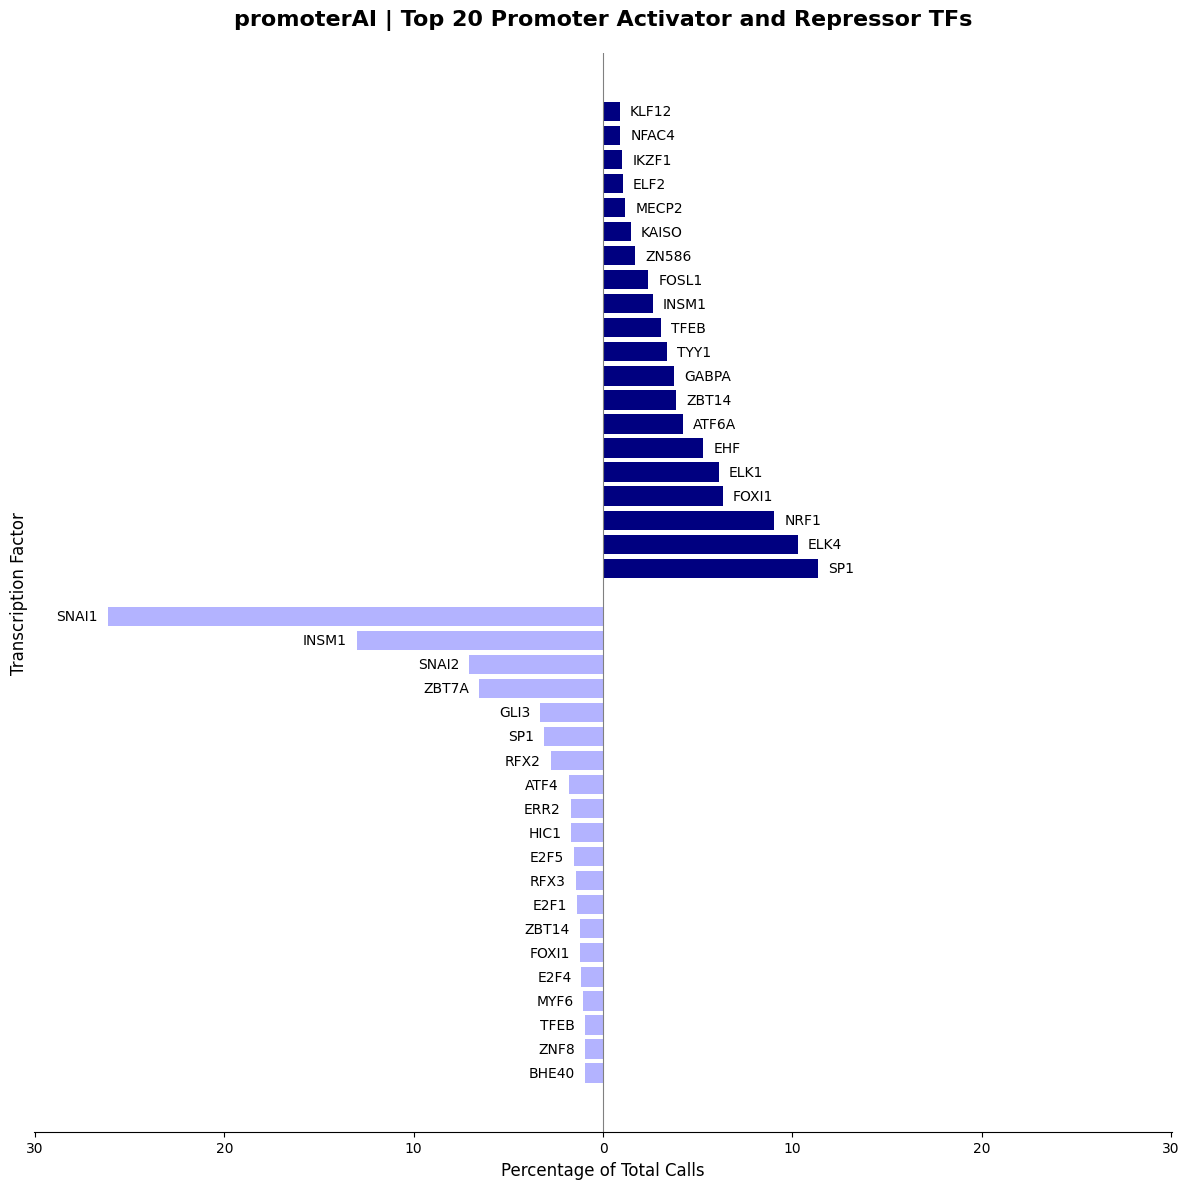

In [66]:
plot_final_diverging_chart(promtoterAI_noMin_collapsed, 'x', 'navy', '#b3b3ff', top_n=20, plot_type='percentages')

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pybedtools

def plot_tss_relative_seqlet_positions(seqlets_bed_path, promoters_bed_path, cell_type, cell_color, output_path):
    """
    Calculates and plots the distribution of seqlet positions relative to the
    Transcription Start Site (TSS) of promoters, accounting for strand.

    Args:
        seqlets_bed_path (str): 
            Path to the seqlet BED file (at least 3 columns: chr, start, end).
        promoters_bed_path (str): 
            Path to the promoter BED file in BED6 format (6 columns: chr, 
            start, end, name, score, strand).
        output_path (str): 
            Path to save the output plot image.
    """
    print("Loading and intersecting BED files...")
    seqlets = pybedtools.BedTool(seqlets_bed_path)
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Intersect to find which seqlets fall within which promoters
    intersection = seqlets.intersect(promoters, wa=True, wb=True)

    # The output will have 10 columns: 4 from seqlets + 6 from promoters
    df_intersect = intersection.to_dataframe(names=[
        'seqlet_chrom', 'seqlet_start', 'seqlet_end', 'seqlet_name',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])
    
    # Ensure coordinate columns are numeric
    for col in ['seqlet_start', 'seqlet_end', 'promo_start', 'promo_end']:
        df_intersect[col] = pd.to_numeric(df_intersect[col], errors='coerce')
    df_intersect.dropna(inplace=True)

    # Calculate the center of each seqlet
    seqlet_center = (df_intersect['seqlet_start'] + df_intersect['seqlet_end']) / 2

    # Calculate the position relative to the TSS using the strand
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        seqlet_center - df_intersect['promo_start'],  # For + strand
        df_intersect['promo_end'] - seqlet_center      # For - strand
    )

    # Plot the distribution of these relative positions
    print("Plotting distribution...")
    plt.figure(figsize=(8, 5), dpi=300)
    sns.kdeplot(data=df_intersect, x='tss_relative_pos', fill=True, color=cell_color, linewidth=2)
    
    plt.title(f'{cell_type} | Distribution of Seqlet Positions Relative to TSS', loc='left')
    plt.xlabel('Distance from Transcription Start Site (bp)')
    mpl.xticks([0, 50, 100, 150, 200, 250],
               [-250, -200, -150, -100, -50, 0])
    plt.ylabel('Density')
    sns.despine()
    plt.tight_layout()
    #plt.savefig(output_path)
    #plt.close()

    #print(f"TSS-relative position plot saved to: {output_path}")

Loading and intersecting BED files...
Plotting distribution...


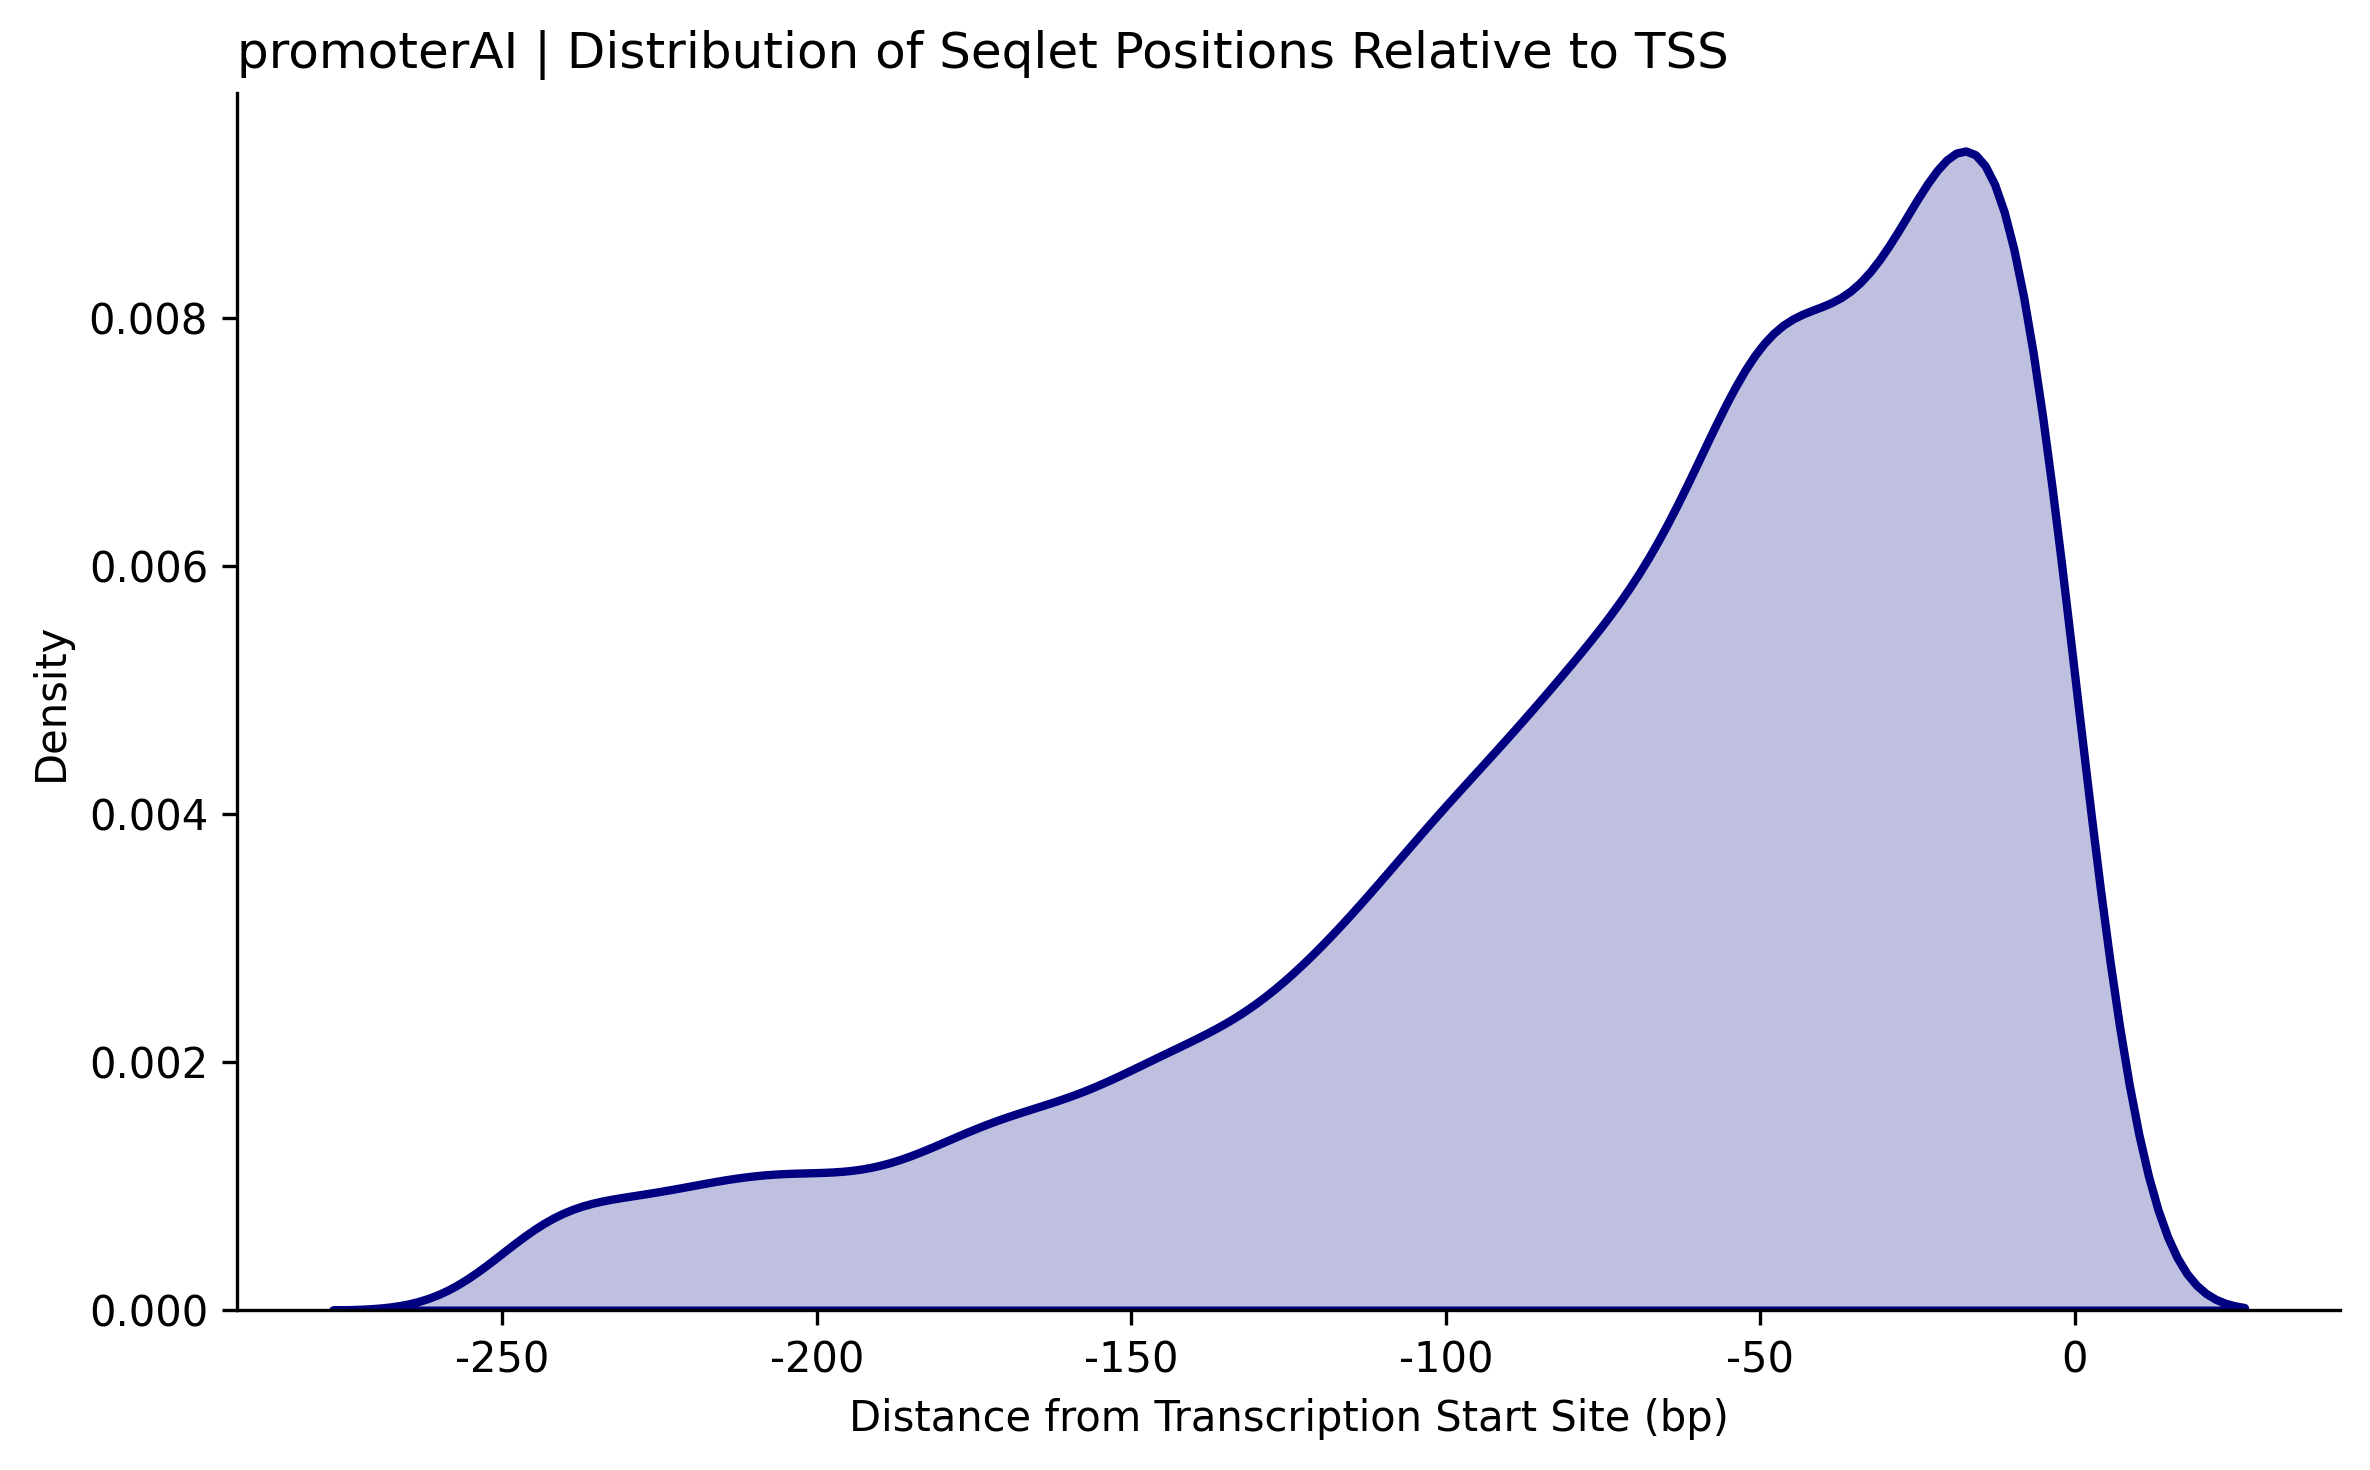

In [71]:
plot_tss_relative_seqlet_positions('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/processed_data/bed_files/promoterAI_bedOps_merged_noMin_seqlets_01.bed',
                                   '../raw_data/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.bed',
                                   'promoterAI',
                                   'navy',
                                   'x')

no seqlets for this enhancer at this threshold


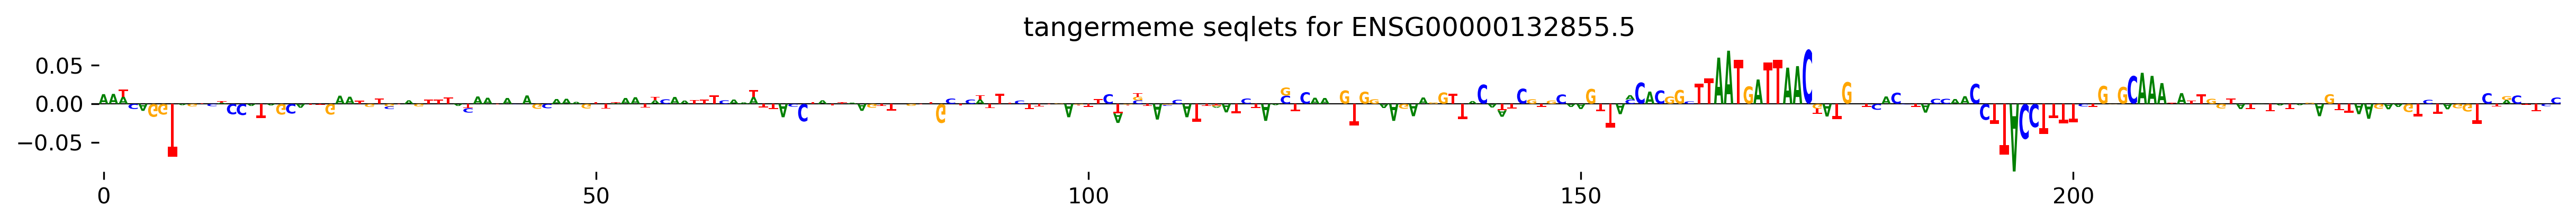

In [25]:
plot_specific_logos(promoterAI_seqlet_calls,
                    full_ann_seqlets,
                    'ENSG00000132855.5',
                    promoterAI_plotLogo_tensors)